<a href="https://colab.research.google.com/github/SoullMk/analytics-lab/blob/main/Atividade_pratica_dataframe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import builtins
vendas = pd.read_excel("datasetteste.xlsx")


In [ ]:
vendas

,id_venda,data,vendedor,produto,estado,qtd,preco_unit,total
0,1,2024-01-05,Ana,Erva Mate 500g,PR,10,18.9,189.0
1,2,2024-01-08,Bruno,Erva Mate 1kg,SC,5,34.5,172.5
2,3,2024-01-12,Ana,Bomba Inox,RS,8,45.0,360.0
3,5,2024-01-20,Bruno,Cuia Artesanal,RJ,3,62.0,186.0
4,6,2024-01-22,Ana,Erva Mate 1kg,ES,12,34.5,414.0
5,7,2024-02-03,Carlos,Bomba Inox,SC,4,45.0,180.0
6,8,2024-02-07,Bruno,Erva Mate 500g,PR,20,18.9,378.0
7,9,2024-02-14,Desconhecido,Cuia Artesanal,RS,2,62.0,124.0
8,10,2024-02-18,Ana,Erva Mate 500g,RJ,7,18.9,132.3
9,11,2024-02-25,Carlos,Erva Mate 1kg,PR,6,34.5,207.0


In [ ]:
# @title EDA
print(f"\nLinhas e colunas: {vendas.shape}")
print(f"Tipo de cada coluna: {vendas.dtypes}")
print(f"Quantos nulos em cada coluna: {vendas.isnull().sum()}")
print(f"Estatisticas gerais: {vendas.describe()}")
print(f"Primeiras 10 linhas: {vendas.head(10)}")


Linhas e colunas: (11, 8)
Tipo de cada coluna: id_venda               int64
data          datetime64[ns]
vendedor              object
produto               object
estado                object
qtd                    int64
preco_unit           float64
total                float64
dtype: object
Quantos nulos em cada coluna: id_venda      0
data          0
vendedor      0
produto       0
estado        0
qtd           0
preco_unit    0
total         0
dtype: int64
Estatisticas gerais:         id_venda                           data        qtd  preco_unit  \
count  11.000000                             11  11.000000   11.000000   
mean    6.727273  2024-01-31 19:38:10.909090816   7.818182   38.109091   
min     1.000000            2024-01-05 00:00:00   2.000000   18.900000   
25%     4.000000            2024-01-16 00:00:00   4.500000   26.700000   
50%     7.000000            2024-02-03 00:00:00   7.000000   34.500000   
75%     9.500000            2024-02-16 00:00:00   9.500000   45.000000

In [ ]:
resultado = vendas.groupby('vendedor')['total'].sum() .sort_values(ascending=False)
resultado.map("R$ {:.2f}".format)

,total
vendedor,
Bruno,R$ 1141.50
Ana,R$ 1095.30
Carlos,R$ 387.00
Desconhecido,R$ 124.00


In [ ]:
resultado = vendas.groupby('produto')['total'].sum() .sort_values(ascending=False)
resultado.map("R$ {:.2f}".format)

,total
produto,
Bomba Inox,R$ 945.00
Erva Mate 1kg,R$ 793.50
Erva Mate 500g,R$ 699.30
Cuia Artesanal,R$ 310.00


In [ ]:
vendas.groupby('estado')['qtd'].sum().sort_values(ascending=False)

,qtd
estado,
PR,36
ES,21
RJ,10
RS,10
SC,9


In [ ]:
vendas['mes'] = vendas['data'].dt.month
vendas.groupby('mes')['total'].sum().sort_values(ascending=False)

,total
mes,
1,1321.5
2,1021.3
3,405.0


In [ ]:
vendas.groupby('estado')['qtd'].sum().sort_values(ascending=False)

,qtd
estado,
PR,36
ES,21
RJ,10
RS,10
SC,9


In [ ]:
vendas.groupby('vendedor')['total'].mean().sort_values(ascending=False)

,total
vendedor,
Bruno,285.375
Ana,273.825
Carlos,193.500
Desconhecido,124.000


In [ ]:
import matplotlib.pyplot as plt

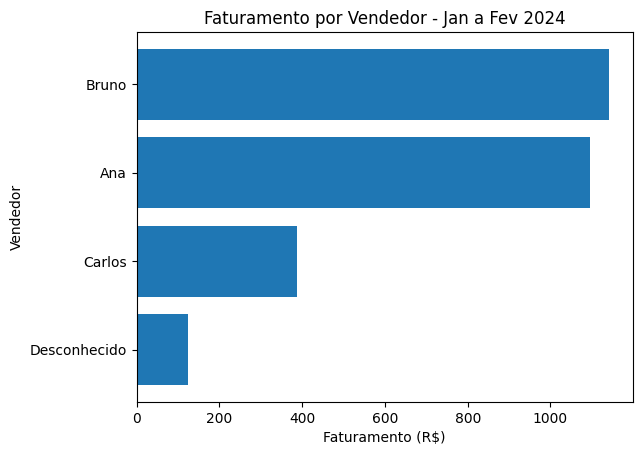

In [ ]:
resultado = vendas.groupby('vendedor')['total'].sum().sort_values(ascending=True)
plt.barh(resultado.index, resultado.values)
plt.xlabel('Faturamento (R$)')
plt.ylabel('Vendedor')
plt.title('Faturamento por Vendedor - Jan a Fev 2024')
plt.show()

In [ ]:
# @title storytelling do conteúdo
#No período observado, de janeiro a fevereiro, o vendedor que teve o maior faturamento foi o Bruno com o valor de 1141,50
#Identificado no ticket médio uma diferença de valor com o primeiro de 285,37 do Bruno, para o ultimo vendedor, que teve um ticket médio de apenas 193,50.
#Vale verificar o por que dessa diferença.
#O estado do Paraná é o estado que mais adquiri os produtos em quantidade
#E por fim a bomba inox é a que mais tem-se faturamento.